# Lab 4 — Synchronization: Carrier, Timing and Frame

**Companion to Chapter 10** (*Synchronization*).
**Time needed:** about 75 minutes. **Difficulty:** core to advanced.

Before a coherent receiver can detect a single bit it must estimate four unknowns:
the carrier **frequency** offset, the carrier **phase**, the symbol **timing** and the
**frame** start. Every one of them is a small estimation problem with a bound on how well
it can be solved, and most are solved by a feedback loop whose bandwidth trades
acquisition speed against noise. This lab builds each piece from scratch (see
`commlib/sync.py`), measures it against theory, and chains them into a burst receiver.

### What you will learn
1. Recognise each synchronization error by its signature on the constellation.
2. Estimate CFO blindly (M-th power) and with a preamble, and compare with the modified Cramér–Rao bound.
3. Design a second-order PLL: loop bandwidth, damping, acquisition, and jitter $\sigma_\phi^2 = B_nT/(E_s/N_0)$.
4. Recover symbol timing with the Gardner detector and read its S-curve.
5. Find frames with a Zadoff–Chu preamble and resolve the PLL's phase ambiguity.

### Prerequisites
Labs 2 and 3 (constellations, RRC matched filtering). Basic feedback-loop ideas (Chapter 10).

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | What each impairment looks like | |
| 2 | Coarse CFO: the M-th power estimator | |
| 3 | How good can a frequency estimate be? (MCRB) | |
| 4 | The second-order PLL: transient and jitter | yes |
| 5 | Symbol timing: the Gardner detector | |
| 6 | Frame synchronization with Zadoff–Chu | |
| 7 | A complete burst receiver | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=4, lab="04")
qpsk = cl.get_constellation("qpsk")
sps = 4
h = cl.rrc_taps(0.35, sps, 10)

Lab 04 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 4


## 1. What each impairment looks like

Learn these four pictures; you will diagnose real receivers with them.

* **Phase offset** $\phi$: the constellation is rotated but still sharp.
* **Frequency offset** $\Delta f$: the rotation grows linearly with time, so points smear
  into rings.
* **Timing offset**: the matched-filter output is sampled off the eye's centre, so each
  point becomes a cloud of ISI.
* **Noise**: circular clouds around the correct points.

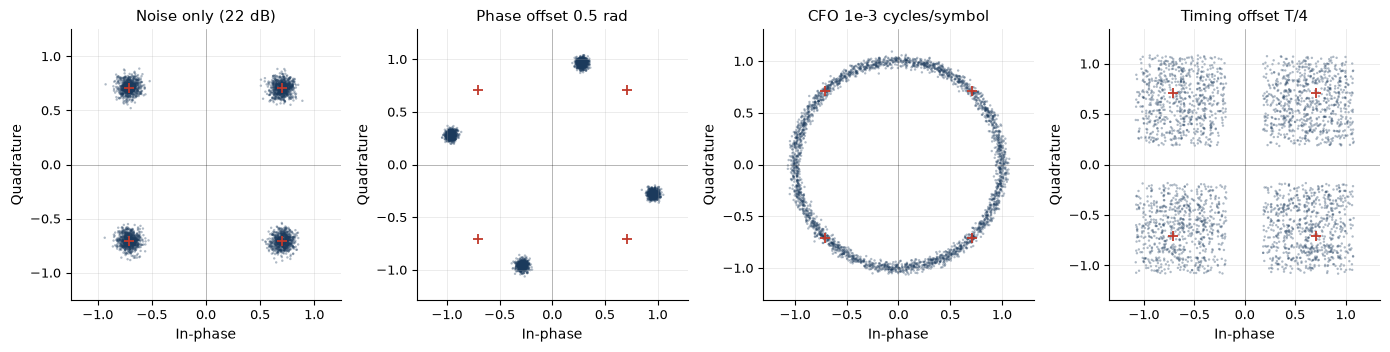

In [3]:
s = qpsk.modulate(cl.random_bits(2 * 3000, rng))
f, ax = lk.fig("row4", 1, 4)
lk.constellation(ax[0], cl.awgn(s, 22, rng), qpsk.points, "Noise only (22 dB)")
lk.constellation(ax[1], cl.awgn(s * np.exp(1j * 0.5), 28, rng), qpsk.points, "Phase offset 0.5 rad")
lk.constellation(ax[2], cl.awgn(cl.apply_cfo(s, 1e-3), 28, rng), qpsk.points, "CFO 1e-3 cycles/symbol")
x = cl.matched_filter(cl.shape(s, h, sps), h)
lk.constellation(ax[3], x[len(h) - 1 + 1::sps][:3000], qpsk.points, "Timing offset T/4")
lk.show(f)

## 2. Coarse CFO: the M-th power estimator

Raising an M-PSK symbol to the $M$-th power removes the modulation:
$(e^{j2\pi m/M})^M = 1$. What is left is a tone at $M\Delta f$, found with an FFT. The
estimate is unambiguous for $|\Delta f| < R_s/(2M)$: for QPSK, $\pm 0.125$ cycles/symbol.

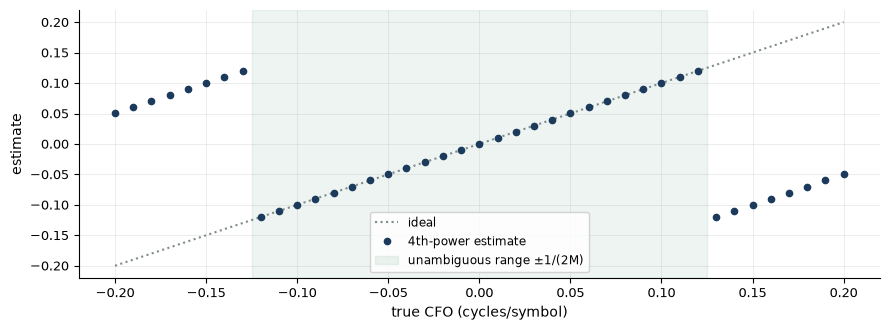

In [5]:
true_f = np.linspace(-0.2, 0.2, 41)
est = [cl.cfo_power_estimate(cl.awgn(cl.apply_cfo(s[:2048], fq), 15, rng), 4) for fq in true_f]
f, ax = lk.fig("wide")
ax.plot(true_f, true_f, color=lk.GRAY, ls=":", label="ideal")
ax.plot(true_f, est, "o", color=lk.NAVY, label="4th-power estimate")
ax.axvspan(-0.125, 0.125, color=lk.GREEN, alpha=0.08, label="unambiguous range ±1/(2M)")
ax.set_xlabel("true CFO (cycles/symbol)"); ax.set_ylabel("estimate"); ax.legend()
lk.show(f)

**What you should see.** Perfect tracking inside the shaded band, then the estimate
wraps: a CFO of 0.15 reads as −0.1. A receiver must therefore know the CFO to within
$R_s/(2M)$ a priori, typically from the oscillator's ppm specification.

### Try it yourself 2.1
A 915 MHz link uses 8-PSK at 50 kBd and both radios have ±10 ppm crystals (so the worst-case
offset is 20 ppm of the carrier). Does the worst-case CFO fit inside the 8th-power
estimator's unambiguous range? Enter the ratio (worst-case CFO) / (half-range $R_s/2M$).

In [7]:
answer_2_1 = None
lk.check("2.1 CFO / unambiguous half-range", answer_2_1, (915e6 * 20e-6) / (50e3 / 16), rtol=0.02,
         hint="worst case = 915e6 * 20e-6 Hz; half-range = Rs / (2*8)")

[TODO] 2.1 CFO / unambiguous half-range: not attempted yet: replace the None with your answer

## 3. How good can a frequency estimate be?

For $N$ symbols at $E_s/N_0$, no unbiased estimator of a constant frequency can beat the
**modified Cramér–Rao bound**

$$\mathrm{MCRB}(\Delta f) = \frac{3}{2\pi^2 N^3\,E_s/N_0}\quad(\text{cycles/symbol})^2 .$$

The $N^3$ is striking: doubling the observation reduces the error variance eightfold,
because a longer window both averages more noise and gives a longer lever arm for measuring
a phase *slope*. We compare the data-aided estimator (remove the known symbols, then find
the peak of the periodogram, refined by parabolic interpolation) and the blind 4th-power
estimator, which suffers a **threshold** at low SNR.

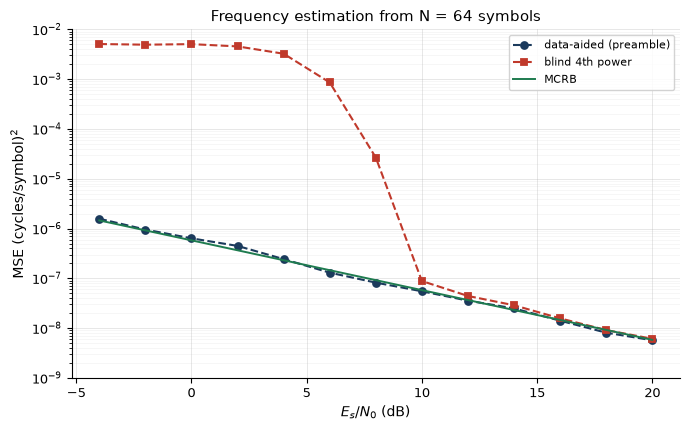

In [9]:
def da_freq(y, a, nfft=None):
    z = y * np.conj(a)                                   # known symbols removed: a noisy tone
    nfft = nfft or 64 * len(z)
    Z = np.abs(np.fft.fft(z, nfft))
    k = int(np.argmax(Z))
    l, c_, r = Z[k - 1], Z[k], Z[(k + 1) % nfft]
    k += 0.5 * (l - r) / (l - 2 * c_ + r)                # parabolic refinement
    return ((k / nfft + 0.5) % 1) - 0.5

N3, trials = 64, 300
snrs = np.arange(-4, 21, 2.0)
mse_da, mse_nda = [], []
for e in snrs:
    ea, en = [], []
    for _ in range(trials):
        fo = rng.uniform(-0.02, 0.02)
        a = qpsk.modulate(cl.random_bits(2 * N3, rng))
        y, _ = cl.awgn_esn0(cl.apply_cfo(a, fo, rng.uniform(0, 6.28)), e, rng=rng)
        ea.append(da_freq(y, a) - fo)
        en.append(cl.cfo_power_estimate(y, 4, nfft=64 * N3) - fo)
    mse_da.append(np.mean(np.square(ea))); mse_nda.append(np.mean(np.square(en)))
snf = np.linspace(-4, 20, 100)
f, ax = lk.fig("ber")
lk.ber_plot(ax, snrs, {"data-aided (preamble)": mse_da, "blind 4th power": mse_nda},
            {"MCRB": 3 / (2 * np.pi ** 2 * N3 ** 3 * lk.undb(snf))}, x_theory=snf,
            xlabel="$E_s/N_0$ (dB)", ylabel="MSE (cycles/symbol)$^2$", ylim=(1e-9, 1e-2))
ax.set_title(f"Frequency estimation from N = {N3} symbols")
lk.show(f)

**What you should see.** The data-aided estimator hugs the MCRB at all SNRs shown. The blind
estimator matches it at high SNR but falls off a cliff below about 9 dB: the 4th power
multiplies noise terms together and, below threshold, noise peaks start to win the FFT search. This is the classic
threshold effect of nonlinear estimators, and the reason standards put a known preamble in
front of every burst.

## 4. The second-order PLL: transient and jitter

A decision-directed PLL computes the phase error $e_k = \arg(z_k\,\hat a_k^*)$, filters it
with a proportional-plus-integral loop filter and updates a numerically controlled
oscillator. Its linear model has two parameters: damping $\zeta$ (0.707 is the usual
choice) and noise bandwidth $B_nT$ (relative to the symbol rate). The integrator lets it
track a frequency offset with zero steady-state phase error. In steady state the phase
jitter is

$$\sigma_\phi^2 \approx \frac{B_nT}{E_s/N_0}\ \text{rad}^2,$$

so halving the loop bandwidth halves the jitter, but also doubles the time to acquire.

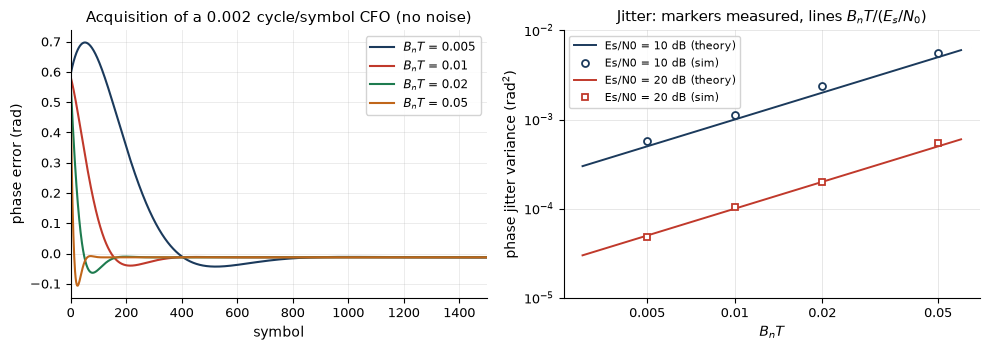

In [12]:
bns = [0.005, 0.01, 0.02, 0.05]
f, ax = lk.fig("row2", 1, 2)
sq = qpsk.modulate(cl.random_bits(2 * 1500, rng))
for bn in bns:
    _, ph = cl.pll_dd(cl.apply_cfo(sq, 0.002, 0.6), qpsk, bn=bn)
    true = 2 * np.pi * 0.002 * np.arange(len(sq)) + 0.6
    ax[0].plot(np.angle(np.exp(1j * (true - ph))), label=f"$B_nT$ = {bn}")
ax[0].set_xlabel("symbol"); ax[0].set_ylabel("phase error (rad)"); ax[0].set_xlim(0, 1500)
ax[0].set_title("Acquisition of a 0.002 cycle/symbol CFO (no noise)"); ax[0].legend()
jit = {}
for es in [10, 20]:
    v = []
    for bn in bns:
        y, _ = cl.awgn_esn0(qpsk.modulate(cl.random_bits(2 * 30000, rng)) * np.exp(0.3j), es, rng=rng)
        _, ph = cl.pll_dd(y, qpsk, bn=bn)
        v.append(np.var(np.angle(np.exp(1j * (ph - 0.3)))[5000:]))
    jit[f"Es/N0 = {es} dB"] = v
bnf = np.linspace(0.003, 0.06, 100)
lk.ber_plot(ax[1], bns, jit, {f"Es/N0 = {es} dB": bnf / lk.undb(es) for es in [10, 20]}, x_theory=bnf,
            xlabel="$B_nT$", ylabel="phase jitter variance (rad$^2$)", ylim=(1e-5, 1e-2))
ax[1].set_xscale("log"); ax[1].set_xticks(bns, [str(b) for b in bns]); ax[1].minorticks_off()
ax[1].set_title("Jitter: markers measured, lines $B_nT/(E_s/N_0)$")
lk.show(f)

**What you should see.** Left: wide loops (0.05) lock within tens of symbols, narrow loops
(0.005) take hundreds; all end at zero phase error thanks to the integrator. Right: the
measured jitter lands on the linear-theory lines: a textbook result confirmed in ten seconds.

### Interactive: PLL playground
Change $B_nT$, CFO and SNR. Push the CFO up with a narrow loop and watch the loop fail to pull in.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

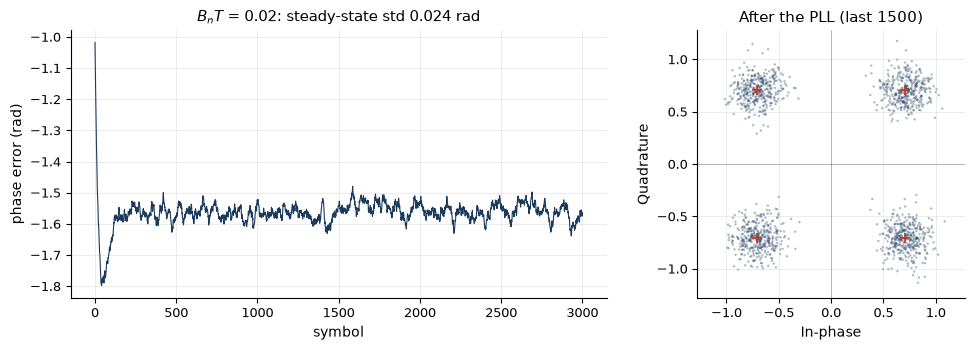

In [14]:
def pll_demo(bn=0.02, cfo=0.002, esn0_db=15.0, mod="qpsk"):
    c = cl.get_constellation(mod)
    sym = c.modulate(cl.random_bits(c.k * 3000, rng))
    y, _ = cl.awgn_esn0(cl.apply_cfo(sym, cfo, 1.0), esn0_db, rng=rng)
    z, ph = cl.pll_dd(y, c, bn=bn)
    true_ph = 2 * np.pi * cfo * np.arange(len(y)) + 1.0
    err = np.angle(np.exp(1j * (ph - true_ph)))
    f, ax = lk.fig("row2", 1, 2, gridspec_kw={"width_ratios": [1.8, 1]})
    ax[0].plot(err, lw=0.8); ax[0].set_xlabel("symbol"); ax[0].set_ylabel("phase error (rad)")
    ax[0].set_title(f"$B_nT$ = {bn}: steady-state std {np.std(err[-1000:] - np.median(err[-1000:])):.3f} rad")
    lk.constellation(ax[1], z[-1500:], c.points, "After the PLL (last 1500)")
    lk.show(f)

lk.interact(pll_demo, bn=lk.slider(0.02, 0.001, 0.1, 0.001, "loop BnT", ".3f"),
            cfo=lk.slider(0.002, 0, 0.02, 0.0005, "CFO (cyc/sym)", ".4f"),
            esn0_db=lk.slider(15, 3, 30, 1, "Es/N0 (dB)"),
            mod=lk.choice(["qpsk", "bpsk", "8psk", "16qam"], desc="modulation"))

**What you should see.** The phase error often settles at a multiple of 90°:
decision-directed loops for QPSK have a four-fold **phase ambiguity** (the constellation
looks the same rotated by 90°). Real systems resolve it with a known preamble (Section 6)
or with differential encoding.

### Try it yourself 4.1
A QPSK link runs at $E_s/N_0 = 12$ dB and the phase jitter must stay below 3° RMS. What is the
largest $B_nT$ you can use?

In [16]:
answer_4_1 = None
lk.check("4.1 largest BnT for 3 deg RMS jitter at 12 dB", answer_4_1, np.deg2rad(3) ** 2 * lk.undb(12),
         rtol=0.03, hint="solve BnT / (Es/N0) = (3 deg in rad)^2")

[TODO] 4.1 largest BnT for 3 deg RMS jitter at 12 dB: not attempted yet: replace the None with your answer

## 5. Symbol timing: the Gardner detector

The Gardner timing-error detector works at 2 or more samples per symbol and does not need
the carrier phase:

$$e[k] = \mathrm{Re}\{y^*(kT - T/2)\,[\,y(kT) - y((k-1)T)\,]\}.$$

Intuition: if a transition occurred, the mid-point sample should be zero; its sign relative to
the direction of the transition says whether we are early or late. The average of $e$ versus
timing offset (the **S-curve**) crosses zero with a slope that sets the loop gain.

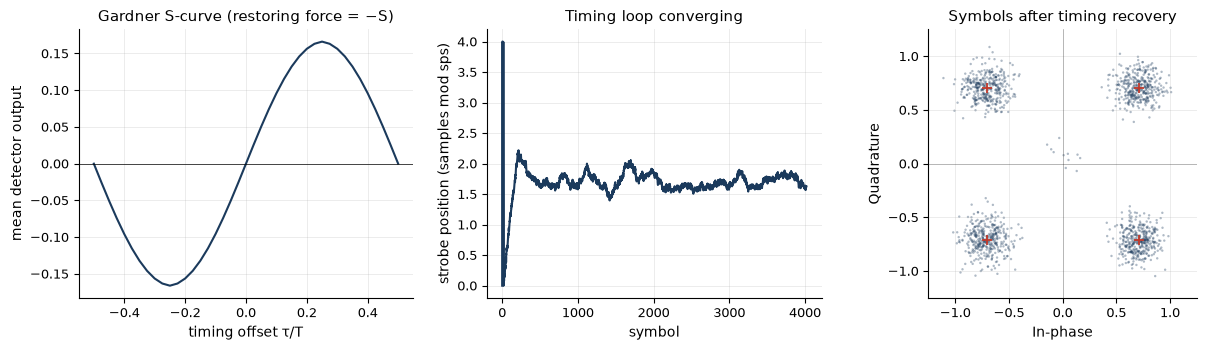

In [18]:
sym = qpsk.modulate(cl.random_bits(2 * 4000, rng))
y = cl.matched_filter(cl.shape(sym, h, sps), h)
d0 = len(h) - 1
taus = np.linspace(-0.5, 0.5, 41)
S = []
for tau in taus:
    tt = d0 + (np.arange(20, 3900) + tau) * sps
    cur, prev, mid = cl.interp_cubic(y, tt), cl.interp_cubic(y, tt - sps), cl.interp_cubic(y, tt - sps / 2)
    S.append(np.mean(np.real(np.conj(mid) * (cur - prev))))
yd = cl.fractional_delay(np.concatenate([y, np.zeros(10)]), 1.7)
yd, _ = cl.awgn_esn0(yd, 20, sps=sps, rng=rng)
syms, e, tau_hist = cl.gardner_sync(yd, sps, bn=0.01)
f, ax = lk.fig("row3", 1, 3)
ax[0].plot(taus, S); ax[0].axhline(0, color="k", lw=0.5); ax[0].set_xlabel("timing offset τ/T")
ax[0].set_ylabel("mean detector output"); ax[0].set_title("Gardner S-curve (restoring force = −S)")
ax[1].plot(tau_hist); ax[1].set_xlabel("symbol"); ax[1].set_ylabel("strobe position (samples mod sps)")
ax[1].set_title("Timing loop converging")
lk.constellation(ax[2], syms[-1500:], qpsk.points, "Symbols after timing recovery")
lk.show(f)

**What you should see.** An S-curve through zero at τ = 0 with positive slope: sampling late
gives a positive average error, early a negative one, and the loop subtracts it, which is a
restoring force back toward the eye centre. The strobe position settles in a few hundred
symbols, and the recovered constellation is clean.

## 6. Frame synchronization with a Zadoff–Chu preamble

CAZAC sequences such as Zadoff–Chu have constant amplitude and ideal periodic
autocorrelation, which is why LTE/NR use them for synchronization signals and PRACH. The
correlation peak gives frame timing; the complex value of the peak gives the channel phase,
resolving the PLL's ambiguity.

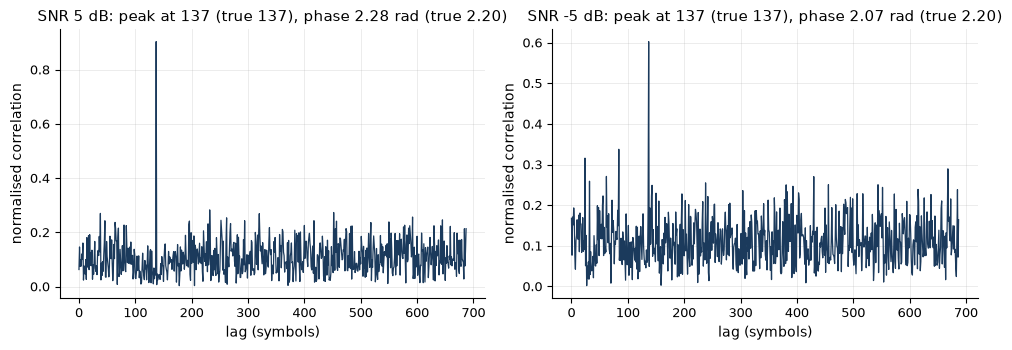

In [21]:
zc = cl.zadoff_chu(25, 63)
payload = qpsk.modulate(cl.random_bits(2 * 500, rng))
burst = np.concatenate([np.zeros(137), zc, payload, np.zeros(50)]) * np.exp(1j * 2.2)
f, ax = lk.fig("row2", 1, 2)
for a, snr in zip(ax, [5, -5]):
    rx = cl.awgn(burst, snr, rng)
    k, g, metric = cl.frame_sync(rx, zc)
    a.plot(metric, lw=0.9); a.set_xlabel("lag (symbols)"); a.set_ylabel("normalised correlation")
    a.set_title(f"SNR {snr} dB: peak at {k} (true 137), phase {np.angle(g):.2f} rad (true 2.20)")
lk.show(f)

**What you should see.** A single sharp peak at lag 137 standing far above the sidelobes,
even at −5 dB SNR: the 63-symbol correlation gives $10\log_{10}63 \approx 18$ dB of processing
gain. The detected phase matches the true channel phase.

## 7. Putting it together: a complete burst receiver

Chain: matched filter → Gardner timing → 4th-power coarse CFO → DD-PLL → preamble correlation
for frame start and phase ambiguity → decisions. The input has a fractional delay, a CFO and
noise, just like an over-the-air burst from `gnuradio/gr02_psk_link.py`.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

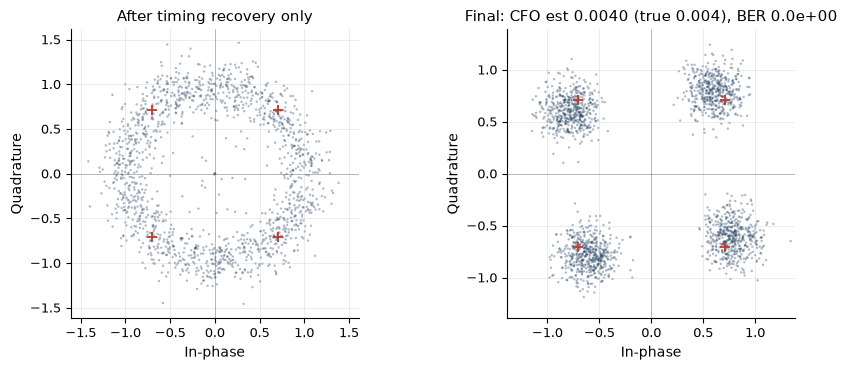

In [24]:
def burst_rx_demo(cfo=0.004, delay=2.3, esn0_db=14.0):
    pre = qpsk.modulate(np.tile([0, 0, 1, 1, 0, 1, 1, 0], 8))   # known 32-symbol preamble
    data_bits = cl.random_bits(2 * 2000, rng)
    tx_sym = np.concatenate([qpsk.modulate(cl.random_bits(2 * 200, rng)), pre, qpsk.modulate(data_bits)])
    xx = cl.shape(tx_sym, h, sps)
    xx = cl.fractional_delay(np.concatenate([xx, np.zeros(20)]), delay)
    xx = cl.apply_cfo(xx, cfo / sps, 0.8)
    xx, _ = cl.awgn_esn0(xx, esn0_db, sps=sps, rng=rng)
    yy = cl.matched_filter(xx, h)
    sy_raw, _, _ = cl.gardner_sync(yy, sps, bn=0.01)
    f_hat = cl.cfo_power_estimate(sy_raw[:1024], 4)
    sy = cl.apply_cfo(sy_raw, -f_hat)
    z, _ = cl.pll_dd(sy, qpsk, bn=0.01)
    k, g, _ = cl.frame_sync(z, pre)
    z = z * np.exp(-1j * np.angle(g))                            # resolve the 90° ambiguity
    data = z[k + len(pre): k + len(pre) + 2000]
    ber = np.mean(qpsk.demodulate(data) != data_bits[:2 * len(data)])
    f, ax = lk.fig((9, 3.8), 1, 2)
    lk.constellation(ax[0], sy_raw[:1500], qpsk.points, "After timing recovery only")
    lk.constellation(ax[1], data, qpsk.points, f"Final: CFO est {f_hat:.4f} (true {cfo}), BER {ber:.1e}")
    lk.show(f)

lk.interact(burst_rx_demo, cfo=lk.slider(0.004, -0.03, 0.03, 0.001, "CFO (cyc/sym)", ".3f"),
            delay=lk.slider(2.3, 0, 4, 0.1, "delay (samples)"),
            esn0_db=lk.slider(14, 4, 30, 1, "Es/N0 (dB)"))

**What you should see.** Left: after timing recovery the CFO smears the symbols into a ring.
Right: after CFO correction, the PLL and the preamble phase fix, four clean clusters and a
BER consistent with Lab 2's curve at that $E_s/N_0$. Push the CFO beyond ±0.125 cycles/symbol
and the receiver fails, exactly as Section 2 predicted.

## Key takeaways
* Each sync error has a signature: rotation (phase), rings (frequency), clouds of ISI (timing).
* Frequency estimation is bounded by the MCRB $\propto 1/(N^3 E_s/N_0)$; blind nonlinear
  estimators pay a threshold at low SNR; preambles avoid it.
* A second-order PLL tracks CFO with zero steady-state error; jitter $= B_nT/(E_s/N_0)$.
* Gardner timing recovery is carrier-independent; its S-curve sets the loop gain.
* Zadoff–Chu preambles give timing, phase (ambiguity resolution) and processing gain.

## Going further (hardware: USRP B200 / GNU Radio)
* `gnuradio/gr02_psk_link.py --sim --cfo 2000 --ppm 50 --snr 15` runs the same chain with GNU
  Radio blocks (FLL band-edge, polyphase clock sync, Costas loop). Change the loop bandwidths
  and compare the lock time with Section 4.
* With a single B200 in cabled loopback TX and RX share one reference, so CFO is ~0: use `--cfo`
  to inject one. With two radios, measure the real ppm offset with Section 3's estimator.

## Exercises
1. **(Warm-up)** Derive the S-curve of the Gardner detector for an RC pulse and compare its
   slope at 0 with the `kd=2` default in `gardner_sync`.
2. **(Core)** Implement the Luise–Reggiannini or Fitz data-aided estimator and add it to the
   MCRB plot. Which one has the widest range?
3. **(Core)** Measure mean acquisition time of the PLL versus $B_nT$ and CFO, and find the
   pull-in limit empirically. Compare with the approximation $\Delta f_{\text{pull-in}} \approx 2\sqrt2\,\zeta B_n$.
4. **(Stretch)** Implement the polyphase-filterbank clock recovery used by GNU Radio's
   `Symbol Sync` block and compare its jitter with the Gardner loop.

In [27]:
lk.summary()

[good] Lab 04 finished in 5.2 s. Self-checks: 0 passed, 0 failed, 2 still to do.